Aprender a personalizar los estilos de Matplotlib permite dar identidad a tus visualizaciones y mantener coherencia en proyectos desarrollados con Python.

En esta guía verás cómo aplicar estilos predefinidos, ajustar tipografías y fondos mediante rcParams, y crear tus propios temas reutilizables con ayuda de NumPy para generar datos de ejemplo y del paquete cycler para definir paletas consistentes.

8.1 Aplicar estilos predefinidos (plt.style.use)
Matplotlib incluye una colección de estilos listos para usar, como "seaborn-v0_8", "ggplot", "bmh", "fivethirtyeight", "dark_background" o "classic".

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


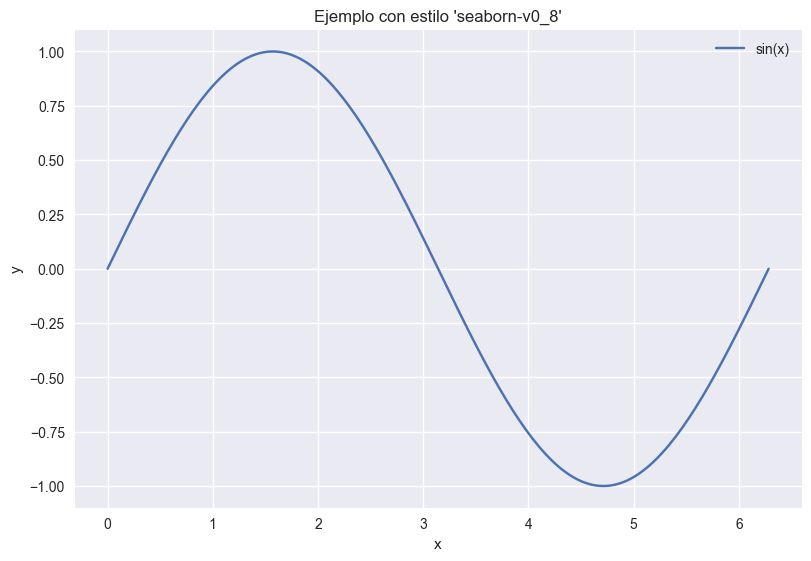

In [1]:
import matplotlib.pyplot as plt
import numpy as np

print(plt.style.available)  # Lista de estilos disponibles

plt.style.use("seaborn-v0_8")  # Aplica estilo global hasta cambiarlo

x = np.linspace(0, 2 * np.pi, 200)
y = np.sin(x)

fig, ax = plt.subplots(layout="constrained")
ax.plot(x, y, label="sin(x)")
ax.set_title("Ejemplo con estilo 'seaborn-v0_8'")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend()
plt.show()

Cambiar estilo temporalmente

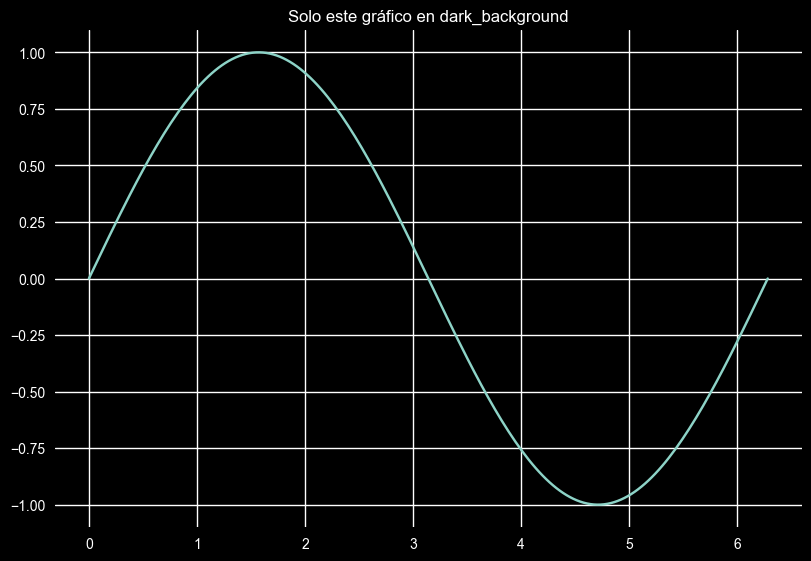

In [2]:
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(0, 2 * np.pi, 200)
y = np.sin(x)

with plt.style.context(["dark_background"]):
    fig, ax = plt.subplots(layout="constrained")
    ax.plot(x, y)
    ax.set_title("Solo este gráfico en dark_background")
    plt.show()

💡 Podés combinar varios estilos pasando una lista; el último sobreescribe las claves previas.

8.2 Cambiar tipografías y fondos
Las preferencias visuales se controlan de forma global con mpl.rcParams o de manera localizada sobre cada figura y eje.

Ajustes globales con rcParams

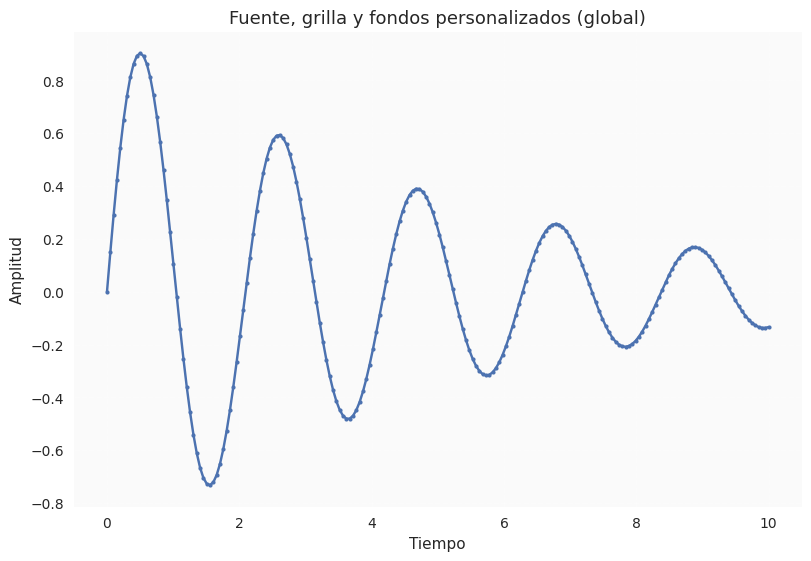

In [3]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

mpl.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "figure.facecolor": "#FFFFFF",
    "axes.facecolor":   "#FAFAFA",
    "axes.edgecolor":   "#333333",
    "axes.grid": True,
    "grid.linestyle": "--",
    "grid.alpha": 0.4,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.frameon": False,
})

x = np.linspace(0, 10, 200)
y = np.exp(-0.2 * x) * np.sin(3 * x)

fig, ax = plt.subplots(layout="constrained")
ax.plot(x, y, marker="o", markersize=3)
ax.set_title("Fuente, grilla y fondos personalizados (global)")
ax.set_xlabel("Tiempo")
ax.set_ylabel("Amplitud")
plt.show()

Ajustes locales por figura

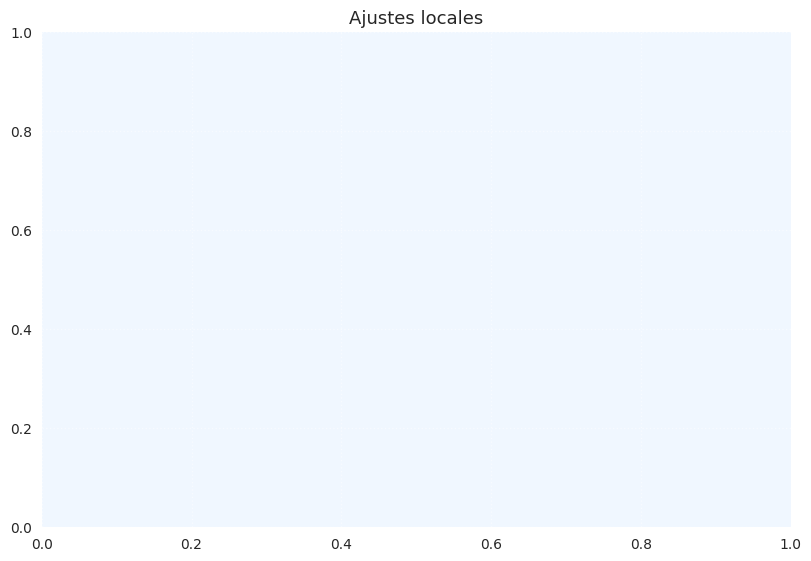

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(layout="constrained")
ax.set_facecolor("#f0f7ff")
fig.set_facecolor("#ffffff")
ax.grid(True, linestyle=":", alpha=0.5)
ax.set_title("Ajustes locales")
plt.show()

Ciclo de colores moderno (cycler)

In [6]:
import matplotlib as mpl
from cycler import cycler

mpl.rcParams["axes.prop_cycle"] = cycler(color=[
    "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728",
    "#9467bd", "#8c564b", "#e377c2", "#7f7f7f"
])

📈 Definir un ciclo garantiza que cada serie reciba colores armónicos y reproducibles.

8.3 Creación de temas personalizados
Podés construir un tema en código o definirlo en un archivo .mplstyle para reutilizarlo en distintos proyectos.

Tema como diccionario en código

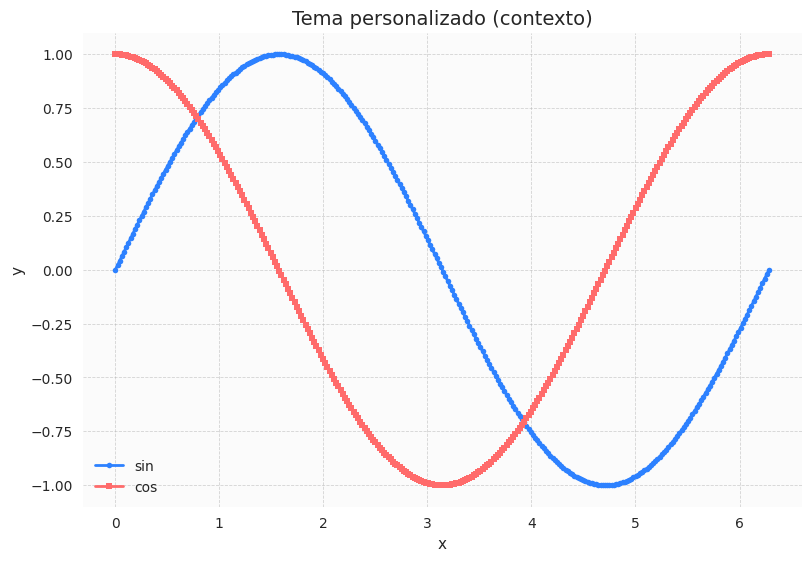

In [7]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from cycler import cycler

mi_tema = {
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "figure.facecolor": "#ffffff",
    "axes.facecolor":   "#fbfbfb",
    "axes.edgecolor":   "#222222",
    "axes.titlesize":   14,
    "axes.labelsize":   11,
    "axes.grid":        True,
    "grid.color":       "#aaaaaa",
    "grid.linestyle":   "--",
    "grid.linewidth":   0.6,
    "grid.alpha":       0.5,
    "legend.frameon":   False,
    "axes.prop_cycle":  cycler(color=["#2D81FF", "#FF6B6B", "#2ECC71", "#F1C40F", "#9B59B6"]),
    "lines.linewidth":  2.0,
    "lines.markersize": 4.0,
}

x = np.linspace(0, 2 * np.pi, 300)

with mpl.rc_context(mi_tema):
    fig, ax = plt.subplots(layout="constrained")
    ax.plot(x, np.sin(x), marker="o", label="sin")
    ax.plot(x, np.cos(x), marker="s", label="cos")
    ax.set_title("Tema personalizado (contexto)")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.legend()
    plt.show()

# Para aplicarlo de forma global:
# mpl.rcParams.update(mi_tema)

Tema en archivo .mplstyle
# mi_tema.mplstyle
font.family: DejaVu Sans
font.size: 11
figure.facecolor: #ffffff
axes.facecolor: #fbfbfb
axes.edgecolor: #222222
axes.titlesize: 14
axes.labelsize: 11
axes.grid: True
grid.color: #aaaaaa
grid.linestyle: --
grid.linewidth: 0.6
grid.alpha: 0.5
legend.frameon: False
lines.linewidth: 2.0
lines.markersize: 4.0
axes.prop_cycle: color: #2D81FF, #FF6B6B, #2ECC71, #F1C40F, #9B59B6
Guardá el archivo en una carpeta reconocida por Matplotlib (por ejemplo, ~/.config/matplotlib/stylelib/ en Linux/macOS o C:\Usuarios\TU_USUARIO\.matplotlib\stylelib\ en Windows).

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

#plt.style.use("mi_tema")           # Si está en stylelib
plt.style.use("./mi_tema.mplstyle")  # Ruta relativa
x = np.linspace(0, 1, 100)
fig, ax = plt.subplots(layout="constrained")
ax.plot(x, x**2, label="x^2")
ax.plot(x, x**3, label="x^3")
ax.set_title("Usando mi_tema.mplstyle")
ax.legend()
plt.show()

OSError: 'mi_tema' is not a valid package style, path of style file, URL of style file, or library style name (library styles are listed in `style.available`)

Buenas prácticas (estilos y temas)
Activá layout="constrained" para evitar solapes sin ajustar márgenes manualmente.
Definí un ciclo de colores propio con cycler para reforzar la identidad visual.
Separá los ajustes globales (.mplstyle) de los cambios puntuales por figura.
Mantené buen contraste entre fondo y datos para garantizar legibilidad.
Documentá el significado de cada color dentro del equipo para asegurar consistencia.
Para impresión o publicaciones, preferí paletas aptas para daltónicos y exportá en SVG o PDF.